In [1]:
from pathlib import Path
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
#Task 7 — Load same CSV and split first
#Load titanic.csv

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "analytics":
    ANALYTICS_DIR = CURRENT_DIR
else:
    ANALYTICS_DIR = CURRENT_DIR / "analytics"

TITANIC_CSV = ANALYTICS_DIR / "titanic.csv"
BEST_PIPELINE_PATH = ANALYTICS_DIR / "best_pipeline.joblib"

df = pd.read_csv(TITANIC_CSV)

print("Dataset loaded from:", TITANIC_CSV)
print("Shape:", df.shape)

df.head()

Dataset loaded from: c:\Code\python\zepto-ai-ml-capstone\analytics\titanic.csv
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
classification_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "sex",
    "embarked",
]

target_column = "survived"

X = df[classification_features].copy()
y = df[target_column].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target_column)

Features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']

Target:
survived


In [4]:
#Report class balance
class_balance = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
})

class_balance.index = [
    "Not Survived (0)",
    "Survived (1)",
]

print("Class balance:")
display(class_balance)

Class balance:


,count,percentage
Not Survived (0),549,61.616162
Survived (1),342,38.383838


In [5]:
#Stratified split BEFORE preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

train_balance = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

test_balance = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

split_balance = pd.DataFrame({
    "Train %": train_balance,
    "Test %": test_balance,
})

display(split_balance)

Training rows: 712
Test rows: 179


,Train %,Test %
survived,,
0,61.657303,61.452514
1,38.342697,38.547486


### Stratified split justification

The target class distribution is not perfectly balanced, so a stratified
train/test split is used to preserve approximately the same survived and
not-survived proportions in both subsets. The percentages above confirm
that the training and test sets retain similar class distributions.

The split is performed before any imputation, encoding, or scaling so that
the test set does not influence fitted preprocessing parameters.

In [6]:
#Task 8 — Training-only preprocessing
#Define preprocessing

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
]

categorical_features = [
    "sex",
    "embarked",
]


numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [7]:
#Task 9 — Three classifiers
#Define models

classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
    ),
}

classifiers

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42)}

In [8]:
#Task 10 — Train and evaluate all three
#Train all classifiers on identical split

fitted_models = {}

classification_results = []

confusion_matrices = {}

roc_results = {}


for model_name, classifier in classifiers.items():

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    # Entire pipeline fits ONLY on training data.
    model_pipeline.fit(
        X_train,
        y_train,
    )

    fitted_models[model_name] = model_pipeline

    y_pred = model_pipeline.predict(X_test)

    y_probability = (
        model_pipeline
        .predict_proba(X_test)[:, 1]
    )

    accuracy = accuracy_score(
        y_test,
        y_pred,
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    auc = roc_auc_score(
        y_test,
        y_probability,
    )

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
    })

    confusion_matrices[model_name] = (
        confusion_matrix(
            y_test,
            y_pred,
        )
    )

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability,
    )

    roc_results[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc,
    }


classification_results_df = pd.DataFrame(
    classification_results
)

display(
    classification_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8156,0.8000,0.6957,0.7442,0.8287


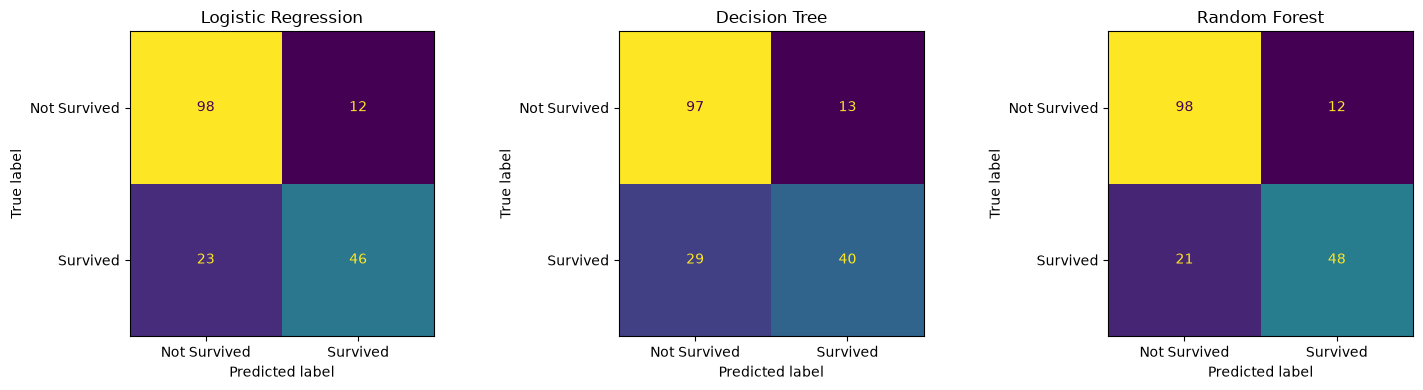

In [9]:
#Confusion matrices
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
)

for ax, (
    model_name,
    matrix,
) in zip(
    axes,
    confusion_matrices.items(),
):

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Not Survived",
            "Survived",
        ],
    )

    display_matrix.plot(
        ax=ax,
        colorbar=False,
    )

    ax.set_title(model_name)

plt.tight_layout()
plt.show()

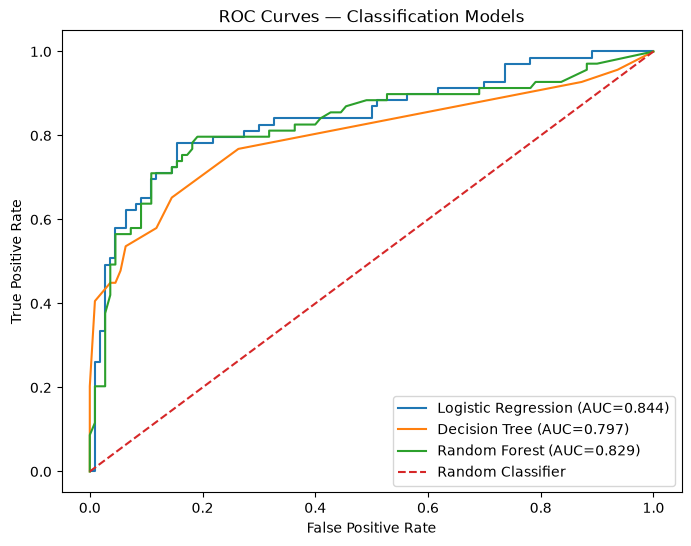

In [10]:
#ROC curves and AUC
plt.figure(figsize=(8, 6))

for model_name, roc_data in roc_results.items():

    plt.plot(
        roc_data["fpr"],
        roc_data["tpr"],
        label=(
            f"{model_name} "
            f"(AUC={roc_data['auc']:.3f})"
        ),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")
plt.legend()

plt.show()

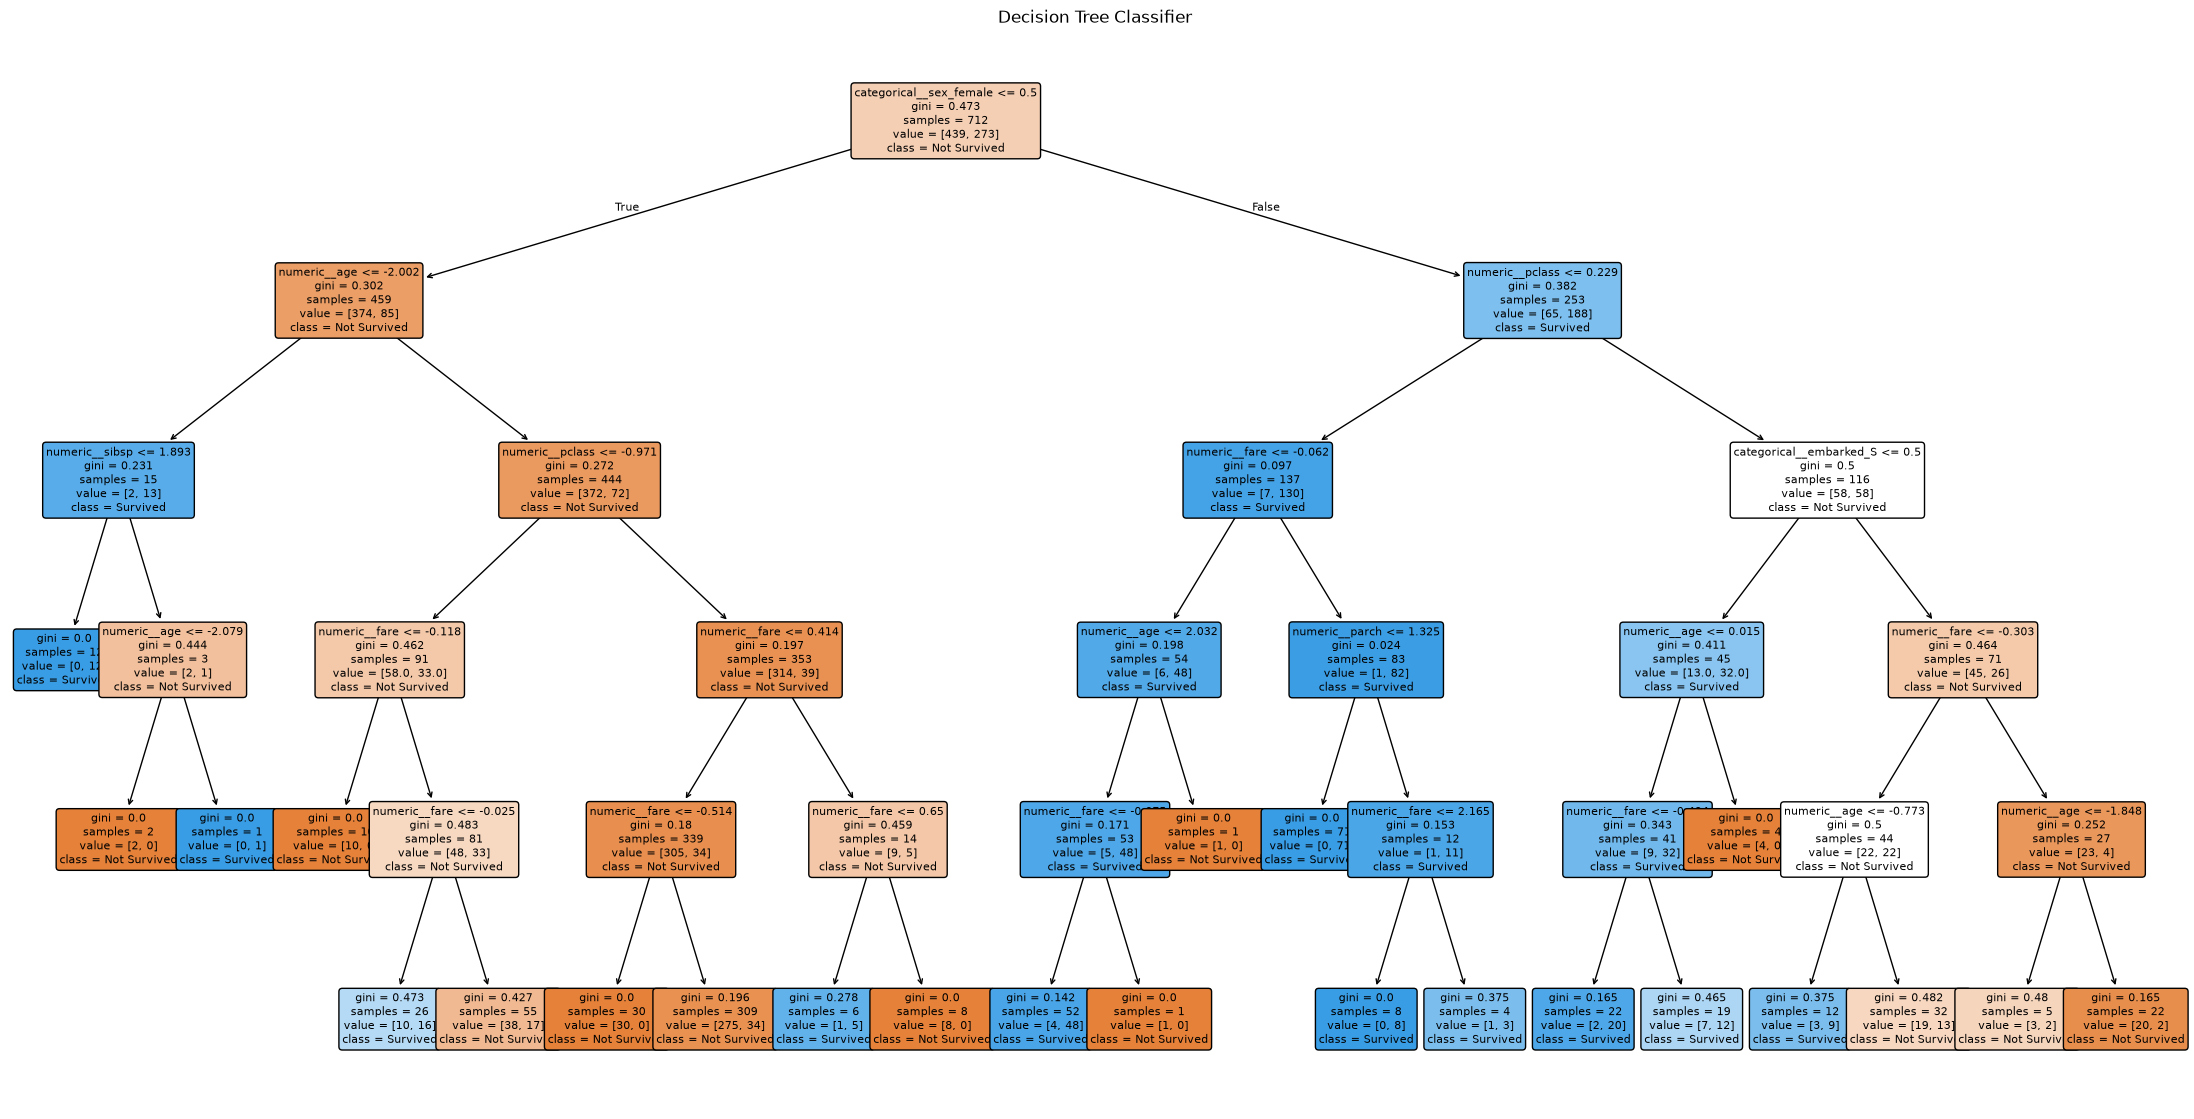

In [11]:
#Task 9 — Required Decision Tree visualization

decision_tree_pipeline = fitted_models[
    "Decision Tree"
]

decision_tree_preprocessor = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
)

decision_tree_model = (
    decision_tree_pipeline
    .named_steps["classifier"]
)

feature_names = (
    decision_tree_preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(28, 14))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived",
    ],
    filled=True,
    rounded=True,
    fontsize=8,
)

plt.title("Decision Tree Classifier")

plt.show()

In [12]:
#Task 11 — Imbalance handling
imbalance_pipelines = {
    "Baseline": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    ),

    "Class Weight Balanced": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),

    "SMOTE": ImbPipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "smote",
                SMOTE(
                    random_state=42,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    ),
}

In [13]:
#Train and compare imbalance strategies

imbalance_results = []

fitted_imbalance_models = {}


for strategy_name, model in imbalance_pipelines.items():

    model.fit(
        X_train,
        y_train,
    )

    fitted_imbalance_models[
        strategy_name
    ] = model

    y_pred = model.predict(X_test)

    imbalance_results.append({
        "Strategy": strategy_name,

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0,
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0,
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0,
        ),
    })


imbalance_results_df = pd.DataFrame(
    imbalance_results
)

display(
    imbalance_results_df.round(4)
)


,Strategy,Precision,Recall,F1
0,Baseline,0.7931,0.6667,0.7244
1,Class Weight Balanced,0.7297,0.7826,0.7552
2,SMOTE,0.7397,0.7826,0.7606


In [14]:
#Identify strongest imbalance result

best_imbalance_row = (
    imbalance_results_df
    .sort_values(
        "F1",
        ascending=False,
    )
    .iloc[0]
)

print(
    "Highest F1 imbalance strategy:",
    best_imbalance_row["Strategy"],
)

print(
    f"Precision: "
    f"{best_imbalance_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_imbalance_row['Recall']:.4f}"
)

print(
    f"F1: "
    f"{best_imbalance_row['F1']:.4f}"
)

Highest F1 imbalance strategy: SMOTE
Precision: 0.7397
Recall: 0.7826
F1: 0.7606


In [15]:
#Task 12 — Random Forest GridSearchCV + OOB
#Build tuning pipeline

rf_tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor),
        ),
        (
            "classifier",
            RandomForestClassifier(
                oob_score=True,
                bootstrap=True,
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

In [16]:
#Parameter grid
rf_param_grid = {
    "classifier__n_estimators": [
        100,
        200,
    ],

    "classifier__max_depth": [
        None,
        5,
        10,
    ],

    "classifier__max_features": [
        "sqrt",
        "log2",
    ],
}

In [17]:
#Run GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True,
)

rf_grid_search.fit(
    X_train,
    y_train,
)

best_rf_pipeline = (
    rf_grid_search.best_estimator_
)

best_rf_model = (
    best_rf_pipeline
    .named_steps["classifier"]
)

print("Best Random Forest parameters:")

for parameter, value in (
    rf_grid_search
    .best_params_
    .items()
):
    print(
        f"{parameter}: {value}"
    )

print(
    "\nOOB score:",
    round(
        best_rf_model.oob_score_,
        4,
    ),
)

Best Random Forest parameters:
classifier__max_depth: 5
classifier__max_features: sqrt
classifier__n_estimators: 100

OOB score: 0.8272


In [18]:
#Task 13 — Regression side-task

#Prepare regression data
regression_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "survived",
    "sex",
    "embarked",
]

X_regression = df[
    regression_features
].copy()

y_regression = df["fare"].copy()


X_train_reg, X_test_reg, y_train_reg, y_test_reg = (
    train_test_split(
        X_regression,
        y_regression,
        test_size=0.20,
        random_state=42,
    )
)

print(
    "Regression training rows:",
    len(X_train_reg),
)

print(
    "Regression test rows:",
    len(X_test_reg),
)

Regression training rows: 712
Regression test rows: 179


In [19]:
#Regression preprocessing

regression_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "survived",
]

regression_categorical_features = [
    "sex",
    "embarked",
]


regression_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)


regression_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent",
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)


regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            regression_numeric_pipeline,
            regression_numeric_features,
        ),
        (
            "categorical",
            regression_categorical_pipeline,
            regression_categorical_features,
        ),
    ]
)

In [20]:
#Fit multivariate linear regression
regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            regression_preprocessor,
        ),
        (
            "regressor",
            LinearRegression(),
        ),
    ]
)


regression_pipeline.fit(
    X_train_reg,
    y_train_reg,
)


fare_predictions = (
    regression_pipeline
    .predict(X_test_reg)
)

In [21]:
#MAE, RMSE, R², Adjusted R²

mae = mean_absolute_error(
    y_test_reg,
    fare_predictions,
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        fare_predictions,
    )
)

r2 = r2_score(
    y_test_reg,
    fare_predictions,
)


# Number of test observations
n = len(y_test_reg)

# Number of transformed predictor columns
X_test_reg_transformed = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_test_reg)
)

p = X_test_reg_transformed.shape[1]


adjusted_r2 = (
    1
    -
    (
        (1 - r2)
        * (n - 1)
        / (n - p - 1)
    )
)


regression_metrics_df = pd.DataFrame(
    {
        "Model": [
            "Multivariate Linear Regression"
        ],

        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2],
        "Adjusted R2": [adjusted_r2],
    }
)

display(
    regression_metrics_df.round(4)
)

,Model,MAE,RMSE,R2,Adjusted R2
0,Multivariate Linear Regression,20.8977,30.5328,0.3975,0.3617


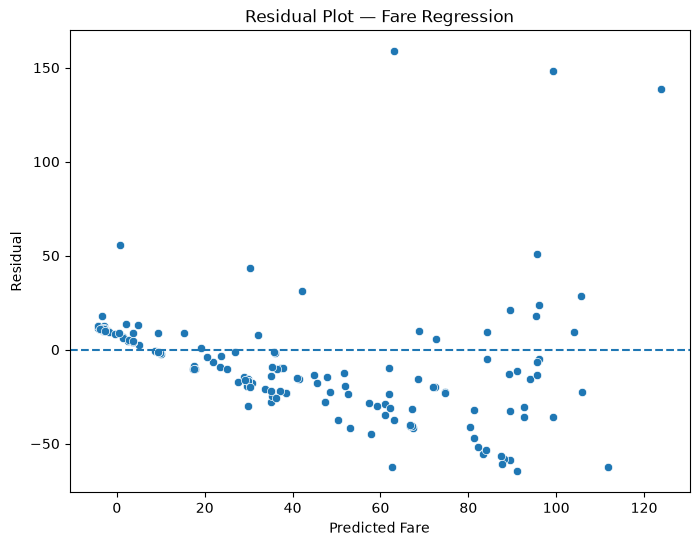

In [22]:
#Residual plot

residuals = (
    y_test_reg
    - fare_predictions
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=fare_predictions,
    y=residuals,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title(
    "Residual Plot — Fare Regression"
)

plt.show()

In [23]:
#Task 14 — Final comparison table

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Linear Regression",
]


column_groups = pd.MultiIndex.from_tuples([
    ("Model", "Name"),

    ("Classification", "Accuracy"),
    ("Classification", "Precision"),
    ("Classification", "Recall"),
    ("Classification", "F1"),
    ("Classification", "AUC"),

    ("Regression", "MAE"),
    ("Regression", "RMSE"),
    ("Regression", "R2"),
    ("Regression", "Adjusted R2"),
])


final_comparison = pd.DataFrame(
    columns=column_groups
)


for _, row in classification_results_df.iterrows():

    final_comparison.loc[
        len(final_comparison)
    ] = [
        row["Model"],
        row["Accuracy"],
        row["Precision"],
        row["Recall"],
        row["F1"],
        row["AUC"],
        np.nan,
        np.nan,
        np.nan,
        np.nan,
    ]


final_comparison.loc[
    len(final_comparison)
] = [
    "Linear Regression",
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    mae,
    rmse,
    r2,
    adjusted_r2,
]


display(
    final_comparison.round(4)
)

Model Classification                                    \
                  Name       Accuracy Precision  Recall      F1     AUC   
0  Logistic Regression         0.8045    0.7931  0.6667  0.7244  0.8437   
1        Decision Tree         0.7654    0.7547  0.5797  0.6557  0.7971   
2        Random Forest         0.8156    0.8000  0.6957  0.7442  0.8287   
3    Linear Regression            NaN       NaN     NaN     NaN     NaN   

  Regression                               
         MAE     RMSE      R2 Adjusted R2  
0        NaN      NaN     NaN         NaN  
1        NaN      NaN     NaN         NaN  
2        NaN      NaN     NaN         NaN  
3    20.8977  30.5328  0.3975      0.3617

In [24]:
#Task 15 — Save the complete best pipeline
#Determine best classifier
best_classifier_row = (
    classification_results_df
    .sort_values(
        "F1",
        ascending=False,
    )
    .iloc[0]
)

best_classifier_name = (
    best_classifier_row["Model"]
)

best_pipeline = (
    fitted_models[
        best_classifier_name
    ]
)

print(
    "Best classifier based on F1:",
    best_classifier_name,
)

print(
    f"F1 score: "
    f"{best_classifier_row['F1']:.4f}"
)

Best classifier based on F1: Random Forest
F1 score: 0.7442


In [25]:
#Save complete fitted pipeline

joblib.dump(
    best_pipeline,
    BEST_PIPELINE_PATH,
)

print(
    "Complete fitted pipeline saved to:",
    BEST_PIPELINE_PATH,
)

Complete fitted pipeline saved to: c:\Code\python\zepto-ai-ml-capstone\analytics\best_pipeline.joblib


In [26]:
#Reload and predict raw data

loaded_pipeline = joblib.load(
    BEST_PIPELINE_PATH
)


raw_sample = (
    X_test
    .iloc[[0]]
    .copy()
)

print("Raw unprocessed input:")
display(raw_sample)


original_prediction = (
    best_pipeline
    .predict(raw_sample)
)

loaded_prediction = (
    loaded_pipeline
    .predict(raw_sample)
)


print(
    "Original pipeline prediction:",
    original_prediction,
)

print(
    "Reloaded pipeline prediction:",
    loaded_prediction,
)

print(
    "Predictions match:",
    np.array_equal(
        original_prediction,
        loaded_prediction,
    ),
)

Raw unprocessed input:


,pclass,age,sibsp,parch,fare,sex,embarked
565,3,24.0,2,0,24.15,male,S


Original pipeline prediction: [0]
Reloaded pipeline prediction: [0]
Predictions match: True
